In [ ]:
# konlpy 패키지 설치: 한국어 형태소 분석을 위한 라이브러리입니다.
!pip install konlpy

In [ ]:
# pandas 라이브러리를 pd라는 이름으로 임포트: 데이터 처리를 위한 주요 라이브러리입니다.
import pandas as pd

# 엑셀 파일을 데이터프레임 형태로 불러오기: 분석할 뉴스 데이터를 불러옵니다.
df = pd.read_excel('/content/medical_conversation_HealthCareMagic.xlsx')


In [ ]:
column_name='text'

In [ ]:
df = df.iloc[:100].copy()

In [ ]:
from konlpy.tag import Kkma

# Kkma 형태소 분석기 객체 생성
kkma = Kkma()

def tokenizer(text):
    try:
        # 입력이 문자열이 아닌 경우 빈 문자열 반환
        if not isinstance(text, str) or not text.strip():
            return ""

        # 형태소 분석 후 명사(NNG, NNP)만 추출
        words = [word for word, tag in kkma.pos(text) if tag in ('NNG', 'NNP','VV','VA') and len(word) > 1]
        # VV 동사 , VA 형용사
        # 결과 반환 (리스트를 문자열로 변환)
        return " ".join(words)

    except Exception as e:
        return ""  # 오류 발생 시 빈 문자열 반환


In [ ]:
# 데이터프레임의 모든 데이터를 문자열 타입으로 변환합니다. 이는 형태소 분석을 위한 준비 단계입니다.
df = df.astype('str')
#'제목_본문' 컬럼에 tokenizer 함수를 적용하여, 형태소 분석을 수행하고 결과를 다시 해당 컬럼에 저장합니다.
df[column_name] = df[column_name].apply(tokenizer)
# 데이터프레임의 모든 열을 문자열 타입으로 변환합니다. 안전한 파일 저장을 위한 단계입니다.
df = df.astype('str')

# 데이터프레임을 '정제파일'로 저장합니다. 분석 결과를 파일로 저장하는 단계입니다.
df.to_excel('정제파일.xlsx')

# 빈도분석 및 워드크라우드 시각화

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer  # CountVectorizer 임포트

cv = CountVectorizer(ngram_range=(1,1))
# ngram_range=(1,1)은 1그램(단어 1개 단위)만 쓰겠다는 뜻

# CountVectorizer를 사용하여 '제목_본문' 컬럼의 텍스트 데이터를 문서-단어 행렬로 변환합니다.
tdm = cv.fit_transform(df[column_name])

# 단어와 그 빈도수를 담은 데이터프레임을 생성합니다. 이는 단어 사용 빈도 분석을 위한 단계입니다.
word_count_tf = pd.DataFrame({'단어': cv.get_feature_names_out(), '빈도': tdm.sum(axis=0).flat})

# 단어 빈도수를 기준으로 내림차순으로 정렬합니다. 이는 가장 자주 사용된 단어를 확인하기 위한 단계입니다.
word_count_tf = word_count_tf.sort_values('빈도', ascending=False)

# 인덱스를 재설정합니다. 이는 데이터의 가독성을 높이기 위한 단계입니다.
word_count_tf = word_count_tf.reset_index(drop=True)
word_count_tf.index = word_count_tf.index + 1

# 단어 빈도수를 'word_count.xlsx' 엑셀 파일로 저장합니다. 결과를 저장하는 단계입니다.
word_count_tf.to_excel('tf_word_count.xlsx')

In [ ]:
#  WordCloud에서 보여질 한글 폰트를 설치합니다.
!apt-get update -qq
!apt-get install fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
# 한글 폰트 경로를 지정합니다. WordCloud에서 한글을 정상적으로 표시하기 위한 준비 단계입니다.
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

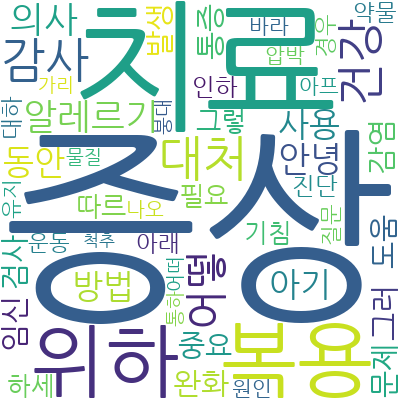

In [ ]:
# WordCloud 라이브러리를 임포트합니다: 텍스트 데이터의 빈도수를 시각화하기 위한 도구입니다.
from wordcloud import WordCloud

# WordCloud 객체를 생성합니다. 여기서는 배경색을 흰색으로, 최대 단어 수를 50개로 설정합니다.
wc = WordCloud(background_color='white', max_words=50, font_path=font_path,width=400, height=400)

# 단어 빈도 사전을 생성합니다. 이는 WordCloud 생성에 사용될 데이터입니다.
count_dic = dict(zip(word_count_tf['단어'], word_count_tf['빈도']))

# WordCloud를 이용해 단어 빈도를 시각화합니다. 이는 가장 많이 사용된 단어를 시각적으로 확인하기 위한 단계입니다.
cloud = wc.fit_words(count_dic)
cloud.to_file('tf_word_cloud.png')
cloud.to_image()